In [9]:
import os
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')

conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

In [ ]:
from typing import TypedDict, List

class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

PLAN_PROMPT = """Eres un escritor especialista con la tarea de crear un esquema de alto nivel para una redacción. \
Escribe este esquema para el tema proporcionado por el usuario. Presenta un plan de la redacción junto con cualesquiera notas \
o instrucciones relevantes para las secciones."""

WRITER_PROMPT = """Eres un asistente de redacción con la tarea de escribir excelentes redacciones de 5 párrafos. \
Genera la mejor redacción posible para la solicitud del usuario y el esquema inicial. Max 500 palabras. \
Si el usuario proporciona críticas, responde con una versión revisada de tus intentos anteriores. \
Utiliza toda la información a continuación según sea necesario:
------------
{content}"""

REFLECTION_PROMPT = """Eres un profesor corrigiendo una redacción presentada. \
Genera una crítica y recomendaciones para la entrega del usuario. \
Proporciona recomendaciones detalladas, incluyendo solicitudes sobre extensión, profundidad, estilo, etc."""

RESEARCH_PLAN_PROMPT = """Eres un investigador encargado de proporcionar información que puede \
ser utilizada al escribir la siguiente redacción. Genera una lista de consultas de investigación que \
recopilen cualquier información relevante. Genera como máximo 3 consultas."""

RESEARCH_CRITIQUE_PROMPT = """Eres un investigador encargado de proporcionar información que puede \
ser utilizada al realizar cualquier revisión solicitada (según se describe a continuación). \
Genera una lista de consultas de investigación que recopilen cualquier información relevante. Genera \
como máximo 3 consultas."""

In [ ]:
from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from tavily import TavilyClient
from langgraph.graph import StateGraph, END


tavily = TavilyClient(api_key=TAVILY_API_KEY)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

class Queries(BaseModel):
    queries: List[str]

def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

def research_plan_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}"
    )
    messages = [
        SystemMessage(
            content=WRITER_PROMPT.format(content=content)
        ),
        user_message
    ]
    response = model.invoke(messages)
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }

def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

#Este research_critique_node es diferente porque el tutor no lo creo, se le pidio a la IA de Codex
def research_critique_node(state: AgentState):
    queries = model.with_structured_output(Queries).invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=2)
        for r in response['results']:
            content.append(r['content'])
    return {"content": content}

def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

In [12]:
builder = StateGraph(AgentState)
builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)
builder.set_entry_point("planner")

builder.add_conditional_edges(
    "generate",
    should_continue,
    {END: END, "reflect": "reflect"}
)

builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")
builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

graph = builder.compile(checkpointer=memory)




--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---


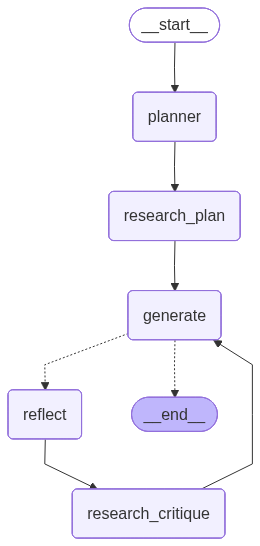

¡Grafo PNG generado y exhibido con éxito!


In [13]:
from IPython.display import Image, display, Markdown
import os

print("\n--- Tratando de Generar el PNG del Grafo vía Mermaid (Requiere Playwright!) ---")
try:
    image_data = graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
    print("¡Grafo PNG generado y exhibido con éxito!")

except Exception as e:
    print(f"\nError al tratar de generar el PNG del grafo: {e}")
    print("Esto posiblemente se debe a que:")
    print("1. El método `.draw_mermaid_png()` no existe en su versión de LangGraph.")
    print("2. Faltan dependencias como 'playwright' o sus drivers no fueron instalados.")
    print("   Trata con: pip install playwright && playwright install")
    print("3. Otro error inesperado al acceder al grafo o renderizar.")

    print("\n--- Tratando generar únicamente el código Mermaid (Fallback) ---")
    try:
        mermaid_code = graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid Generado (Pégalo en https://mermaid.live/ o utiliza Markdown en un entorno compatible) ---")
        print(mermaid_code)
    
    except Exception as e_mermaid:
        print(f"Error al generar el código Mermaid: {e_mermaid}")
        print("Verifica si `graph.get_graph()` está correcto y es accesible.")

In [ ]:
from langchain_core.callbacks import UsageMetadataCallbackHandler

callback = UsageMetadataCallbackHandler()

thread = {
    "configurable": {"thread_id": "5"},
    "callbacks": [callback]
}


for s in graph.stream({
    "task": "Cuál es la diferencia entre LangChain y LangSmith",
    "max_revisions": 2,
    "revision_number": 1,
    "content": [],
}, thread):
    print(s)

print("Tokens consumidos:", callback.usage_metadata)



{'planner': {'plan': 'Aquí tienes un esquema de alto nivel para una redacción sobre la diferencia entre LangChain y LangSmith:\n\n## Esquema de Redacción: LangChain vs. LangSmith - Comprendiendo sus Roles en el Desarrollo de Aplicaciones con LLM\n\n**Objetivo de la Redacción:** Explicar claramente las funciones y diferencias fundamentales entre LangChain y LangSmith, destacando cómo se complementan en el ciclo de vida del desarrollo de aplicaciones basadas en Modelos de Lenguaje Grandes (LLM).\n\n---\n\n**I. Introducción**\n\n*   **A. Gancho:** La explosión de las aplicaciones basadas en LLM y la necesidad de herramientas robustas para su desarrollo y depuración.\n*   **B. Presentación de LangChain y LangSmith:** Breve mención de ambos como componentes clave en este ecosistema.\n*   **C. Declaración de Tesis:** LangChain es un *framework* para construir aplicaciones con LLM, mientras que LangSmith es una *plataforma* para observar, depurar y mejorar esas aplicaciones construidas con La